# Cloud Adoption and Business Efficiency Improvement Percentage Prediction

## Objective
This project predicts **how much (%) business efficiency improves** after adopting cloud computing.

## Dataset
Dataset used: **business_efficiency_percentage_dataset.csv**

Features:
- `cloud_adoption` (0/1)
- `usage_frequency` (1–5)
- `training` (0/1)
- `integration` (0/1)

Target:
- `efficiency_improvement_percent`

## Model
Since the target is a continuous percentage value, **Linear Regression** is used.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving efficiency_percent_dataset.csv to efficiency_percent_dataset (2).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("efficiency_percent_dataset.csv")
df.head()

,cloud_adoption,usage_frequency,training,integration,efficiency_improvement_percent
0,0,1,0,0,29.270921
1,1,1,1,0,41.915871
2,0,3,1,1,42.647582
3,0,2,1,1,45.126987
4,0,5,0,0,42.962479


In [ ]:
print("Shape of dataset:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Shape of dataset: (300, 5)

Missing values:
 cloud_adoption                    0
usage_frequency                   0
training                          0
integration                       0
efficiency_improvement_percent    0
dtype: int64

Data types:
 cloud_adoption                      int64
usage_frequency                     int64
training                            int64
integration                         int64
efficiency_improvement_percent    float64
dtype: object


In [ ]:
df.describe()

,cloud_adoption,usage_frequency,training,integration,efficiency_improvement_percent
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,0.496667,2.970000,0.440000,0.510000,41.424412
std,0.500824,1.422149,0.497216,0.500735,5.591541
min,0.000000,1.000000,0.000000,0.000000,27.545895
25%,0.000000,2.000000,0.000000,0.000000,37.665611
50%,0.000000,3.000000,0.000000,1.000000,41.674362
75%,1.000000,4.000000,1.000000,1.000000,45.419727
max,1.000000,5.000000,1.000000,1.000000,50.000000


## Data Visualization

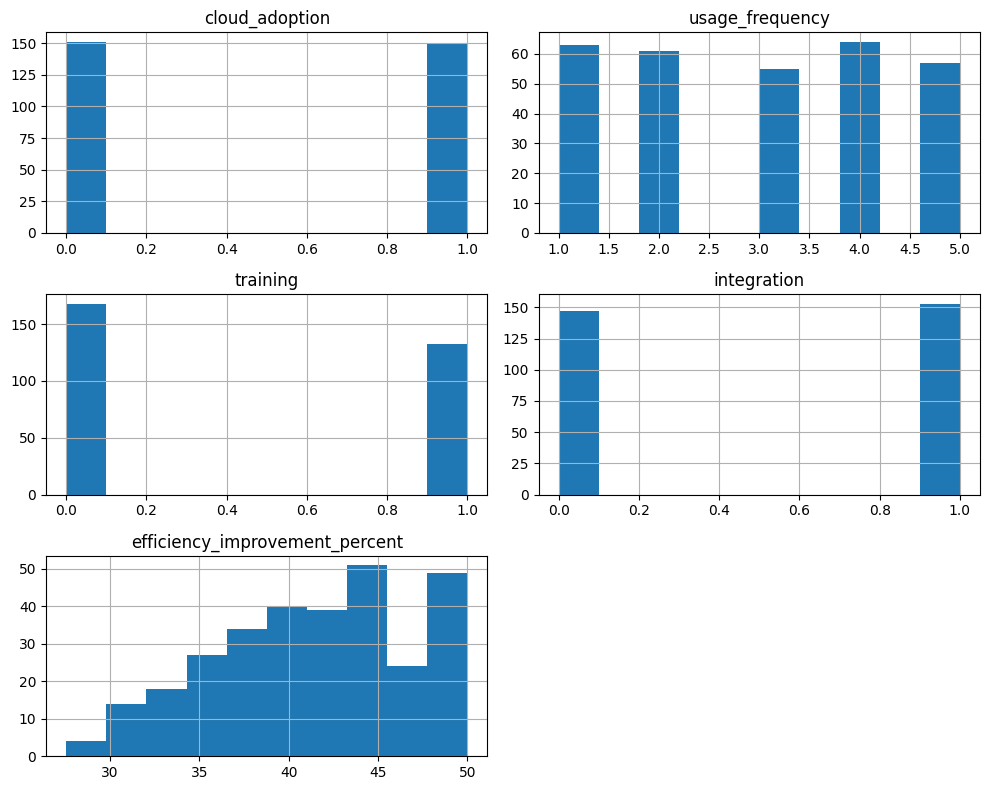

In [ ]:
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

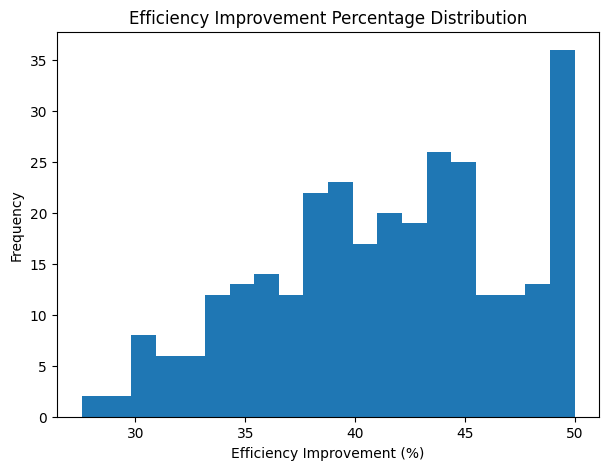

In [ ]:
plt.figure(figsize=(7,5))
plt.hist(df["efficiency_improvement_percent"], bins=20)
plt.title("Efficiency Improvement Percentage Distribution")
plt.xlabel("Efficiency Improvement (%)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
X = df.drop("efficiency_improvement_percent", axis=1)
y = df["efficiency_improvement_percent"]

print("Features:\n", X.head())
print("\nTarget:\n", y.head())

Features:
    cloud_adoption  usage_frequency  training  integration
0               0                1         0            0
1               1                1         1            0
2               0                3         1            1
3               0                2         1            1
4               0                5         0            0

Target:
 0    29.270921
1    41.915871
2    42.647582
3    45.126987
4    42.962479
Name: efficiency_improvement_percent, dtype: float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (240, 4)
Testing set shape: (60, 4)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

## Model Evaluation

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R2 Score:", round(r2, 4))

Mean Absolute Error (MAE): 2.8
Mean Squared Error (MSE): 11.27
Root Mean Squared Error (RMSE): 3.36
R2 Score: 0.6248


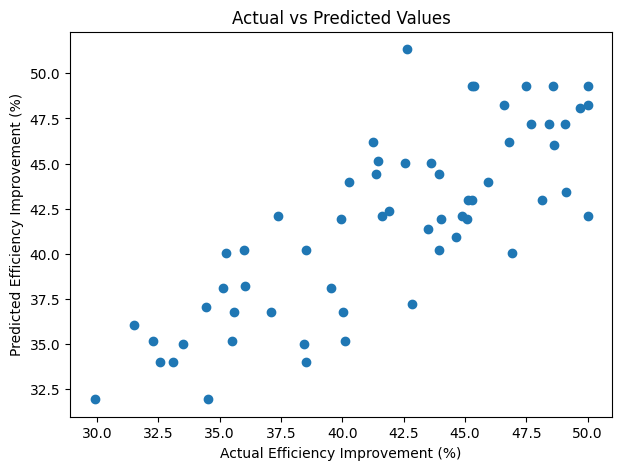

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Efficiency Improvement (%)")
plt.ylabel("Predicted Efficiency Improvement (%)")
plt.title("Actual vs Predicted Values")
plt.show()

## Feature Impact

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print(coefficients)

           Feature  Coefficient
0   cloud_adoption     4.848261
3      integration     3.235545
2         training     3.067276
1  usage_frequency     2.064837


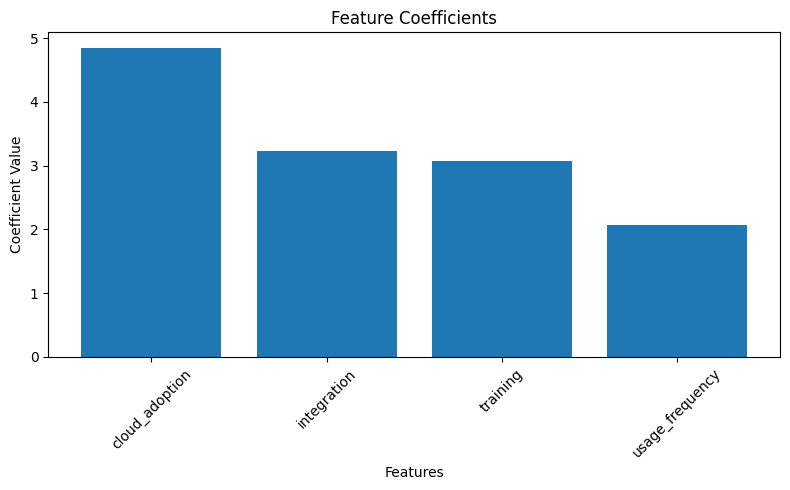

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(coefficients["Feature"], coefficients["Coefficient"])
plt.title("Feature Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Interpretation

- A positive coefficient means that the factor increases business efficiency improvement percentage.
- A higher coefficient means a stronger positive impact.

## Conclusion

This model estimates **how much business efficiency improves in percentage terms** after cloud adoption.

Using the dataset **business_efficiency_percentage_dataset.csv**, we conclude that cloud adoption, training, usage frequency, and integration positively influence business efficiency improvement.